In [1]:
import os
import sys
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from fredapi import Fred
import matplotlib.pyplot as plt
sys.path.append("..") 


MEGACAPS = [
    "AAPL","MSFT","AMZN","GOOGL", "NVDA","JNJ","JPM","V",
    "MA","PG","HD","DIS","BAC","WMT","TSLA","ADBE","NFLX","INTC"
]

BENCHMARK = "SPY" 

START = "2024-01-01"
END = "2025-01-01"

In [2]:
load_dotenv()
fred_key = os.environ["FRED_API_KEY"]

fred = Fred(api_key=fred_key)   
rf_annual = fred.get_series(
    "DTB3",
    observation_start=START,
    observation_end=END
)

rf_annual.to_csv("../data/DTB3.csv")
rf_daily = (np.log(1 + rf_annual/100) / 252).fillna(0)
rf_daily = rf_daily.iloc[1:-1].to_frame().reset_index(names="Date").rename(columns={0:"rf_daily"})
rf_daily["Date"] = pd.to_datetime(rf_daily["Date"])

Text(0, 0.5, 'excess_stock_risk')

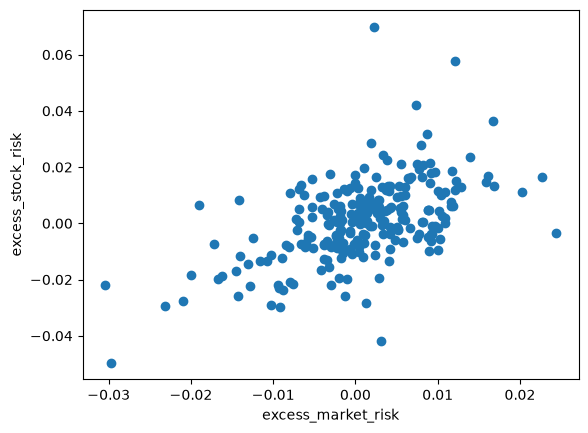

In [3]:
df = pd.read_csv("../data/AAPL.csv")
benchmark_df = pd.read_csv("../data/SPY.csv")

df["Date"] = pd.to_datetime(df["Date"])
benchmark_df["Date"] = pd.to_datetime(benchmark_df["Date"])

df["log_return"] = np.log(df["Close"]).diff()
benchmark_df["log_return"] = np.log(benchmark_df["Close"]).diff()

temp = pd.merge(df[["Date", "log_return"]], benchmark_df[["Date", "log_return"]], 
                  on="Date", suffixes=("_stock", "_mkt"))

merged = pd.merge(temp, rf_daily, on="Date", how="inner")

merged["excess_stock"] = merged["log_return_stock"] - merged["rf_daily"]
merged["excess_mkt"] = merged["log_return_mkt"] - merged["rf_daily"]

merged = merged.dropna(subset=["excess_stock", "excess_mkt"])

plt.scatter(merged["excess_mkt"], merged["excess_stock"])
plt.xlabel("excess_market_risk")
plt.ylabel("excess_stock_risk")

In [4]:
market = merged["excess_mkt"]
stock = merged["excess_stock"]

beta = np.cov(stock, market)[0, 1] / np.var(market, ddof=1)
alpha = np.mean(stock) - beta * np.mean(market)
resid = stock - (alpha + beta * market)
sigma_eps2 = np.var(resid, ddof=2) 
print(f"beta: {beta:.4f}| alpha: {alpha:.4f}")

beta: 0.9575| alpha: 0.0003


#### Single Stock (Random Walk)

In [5]:
from src.main import KalmanBetaFilter as kf

In [8]:
aapl = pd.read_csv("../data/AAPL.csv", parse_dates=["Date"]).set_index("Date")
spy = pd.read_csv("../data/SPY.csv", parse_dates=["Date"]).set_index("Date")

r_stock = np.log(aapl["Close"]).diff().dropna()
r_mkt = np.log(spy["Close"]).diff().dropna()
r_stock, r_mkt = r_stock.align(r_mkt, join="inner")

betas = kf.run_filter(np.array([alpha, beta]), sigma_eps2, r_stock, r_mkt, warmup=60)
print(betas.tail())
print(f"\nMean beta: {betas['beta'].mean():.3f}, "
      f"std: {betas['beta'].std():.3f}")

               alpha      beta   P_alpha    P_beta
date                                              
2024-12-24  0.003927  0.905811  0.000033  0.012739
2024-12-26  0.003736  0.905965  0.000033  0.012832
2024-12-27  0.001995  0.912582  0.000033  0.012787
2024-12-30  0.000870  0.916194  0.000033  0.012785
2024-12-31 -0.000207  0.916305  0.000033  0.012885

Mean beta: 0.963, std: 0.022
